1. Data Exploration
- Inspect dataset dimensions
- Check column names and data types

2. Data Preprocessing
- Sort observations by date
- Remove duplicates
- Handle missing values
- Prepare the target variable: BORE_OIL_VOL
- Visualize oil production over time

3. Feature Engineering
- Create lag features
- Create rolling statistics
- Prepare data for forecasting models

1. Data Exploration

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [ ]:
# Read data
data_path = Path("../data/Raw_prod_data.xlsx")
df = pd.read_excel(data_path)
df = df.sort_values("DATEPRD")
print(df.head())

# Inspect dataset dimension
print("Dataset shape:", df.shape)

     DATEPRD  WELL_BORE_CODE  NPD_WELL_BORE_CODE NPD_WELL_BORE_NAME  \
0 2007-09-01  NO 15/9-F-4 AH                5693           15/9-F-4   
1 2007-09-01  NO 15/9-F-5 AH                5769           15/9-F-5   
2 2007-09-02  NO 15/9-F-4 AH                5693           15/9-F-4   
3 2007-09-02  NO 15/9-F-5 AH                5769           15/9-F-5   
4 2007-09-03  NO 15/9-F-4 AH                5693           15/9-F-4   

   NPD_FIELD_CODE NPD_FIELD_NAME  NPD_FACILITY_CODE NPD_FACILITY_NAME  \
0         3420717          VOLVE             369304    MÆRSK INSPIRER   
1         3420717          VOLVE             369304    MÆRSK INSPIRER   
2         3420717          VOLVE             369304    MÆRSK INSPIRER   
3         3420717          VOLVE             369304    MÆRSK INSPIRER   
4         3420717          VOLVE             369304    MÆRSK INSPIRER   

   ON_STREAM_HRS  AVG_DOWNHOLE_PRESSURE  ...  AVG_CHOKE_UOM  AVG_WHP_P  \
0            NaN                    NaN  ...            NaN 

In [20]:
# Check column names and data types
print(df.dtypes)

DATEPRD                     datetime64[ns]
WELL_BORE_CODE                      object
NPD_WELL_BORE_CODE                   int64
NPD_WELL_BORE_NAME                  object
NPD_FIELD_CODE                       int64
NPD_FIELD_NAME                      object
NPD_FACILITY_CODE                    int64
NPD_FACILITY_NAME                   object
ON_STREAM_HRS                      float64
AVG_DOWNHOLE_PRESSURE              float64
AVG_DOWNHOLE_TEMPERATURE           float64
AVG_DP_TUBING                      float64
AVG_ANNULUS_PRESS                  float64
AVG_CHOKE_SIZE_P                   float64
AVG_CHOKE_UOM                       object
AVG_WHP_P                          float64
AVG_WHT_P                          float64
DP_CHOKE_SIZE                      float64
BORE_OIL_VOL                       float64
BORE_GAS_VOL                       float64
BORE_WAT_VOL                       float64
BORE_WI_VOL                        float64
FLOW_KIND                           object
WELL_TYPE  

In [21]:
wells = df['WELL_BORE_CODE'].unique()
print(wells)

['NO 15/9-F-4 AH' 'NO 15/9-F-5 AH' 'NO 15/9-F-12 H' 'NO 15/9-F-14 H'
 'NO 15/9-F-11 H' 'NO 15/9-F-15 D' 'NO 15/9-F-1 C']


There are 7 wells in total. We only use data of one well to predict oil production

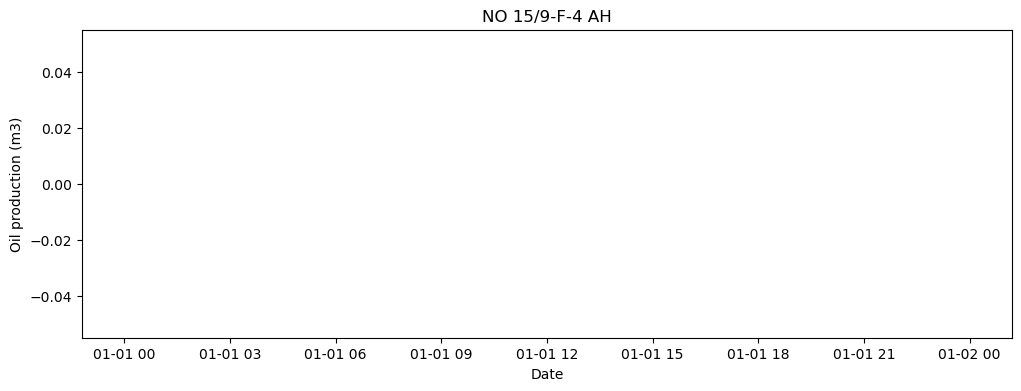

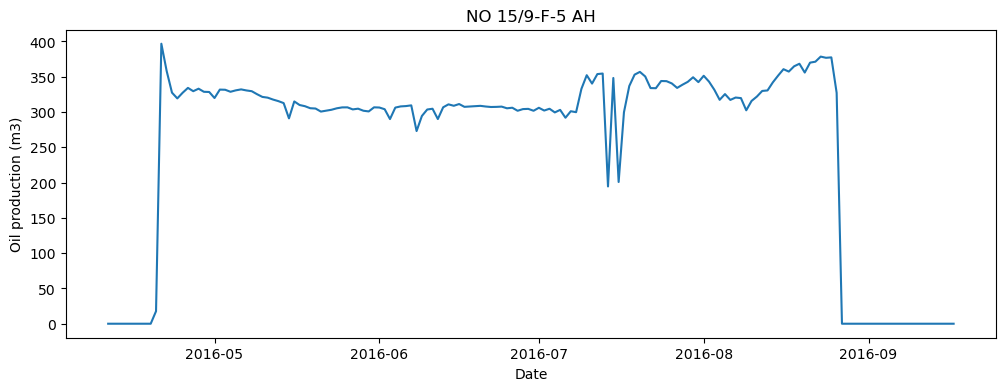

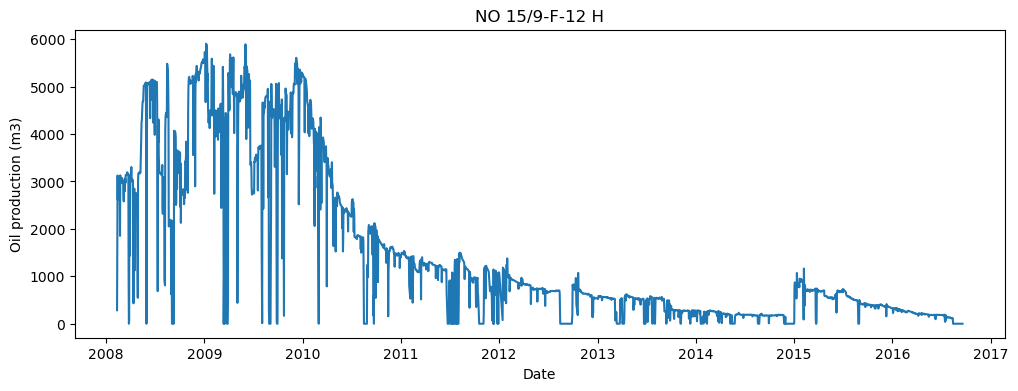

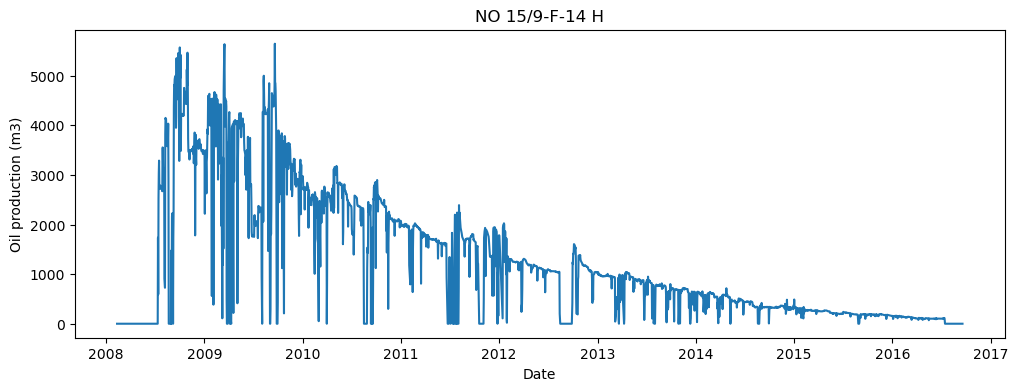

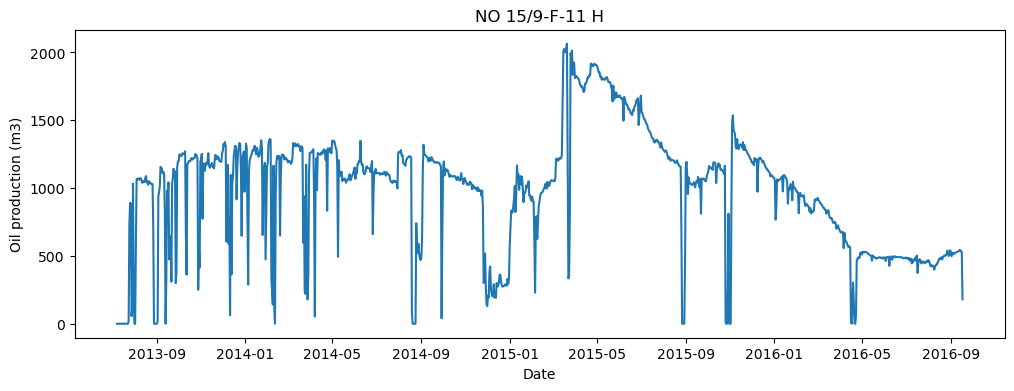

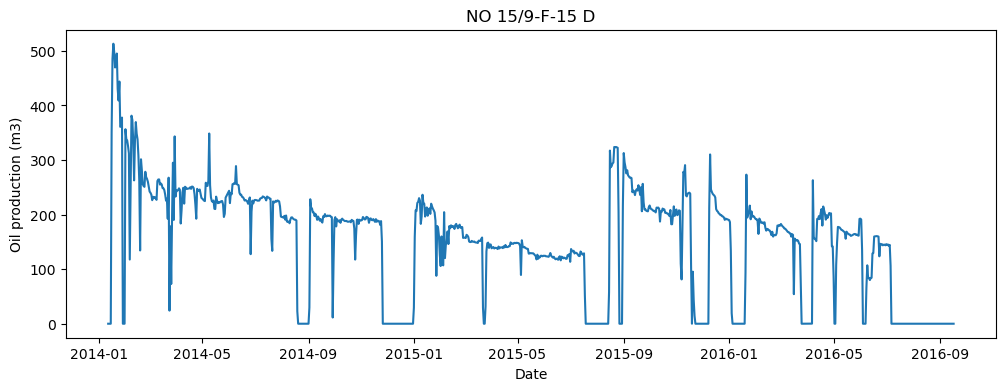

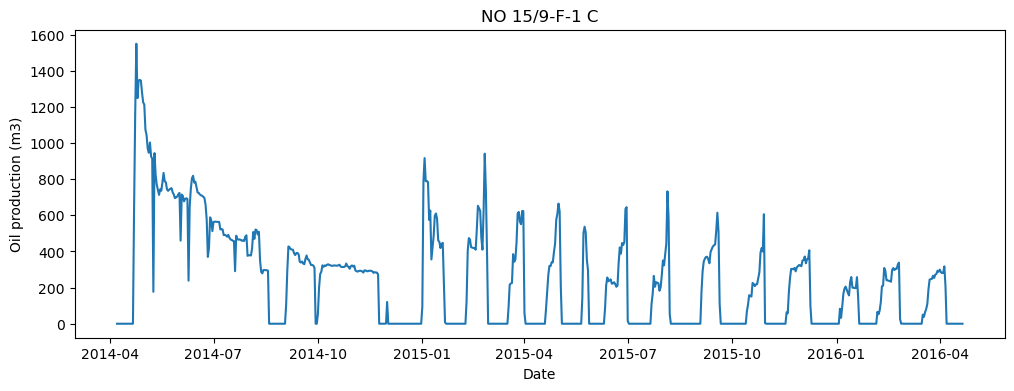

In [26]:
# Analyze each well's production data
# Plot one chart per well
for well in wells:
    well_data = df[df["WELL_BORE_CODE"] == well]

    plt.figure(figsize=(12, 4))
    plt.plot(
        well_data["DATEPRD"],
        well_data["BORE_OIL_VOL"]
    )
    plt.title(well)
    plt.xlabel("Date")
    plt.ylabel("Oil production (m3)")

2. Data preprocessing

In [ ]:
# Remove duplicates
df.drop_duplicates(inplace=True)
df.shape

(9161, 12)

In [8]:
# Analyze missing values
df.isna().sum()

DATEPRD                        0
WELL_BORE_CODE                 0
NPD_WELL_BORE_CODE             0
NPD_WELL_BORE_NAME             0
NPD_FIELD_CODE                 0
NPD_FIELD_NAME                 0
NPD_FACILITY_CODE              0
NPD_FACILITY_NAME              0
ON_STREAM_HRS                285
AVG_DOWNHOLE_PRESSURE       6654
AVG_DOWNHOLE_TEMPERATURE    6654
AVG_DP_TUBING               6654
AVG_ANNULUS_PRESS           7744
AVG_CHOKE_SIZE_P            6715
AVG_CHOKE_UOM               6473
AVG_WHP_P                   6479
AVG_WHT_P                   6488
DP_CHOKE_SIZE                294
BORE_OIL_VOL                6473
BORE_GAS_VOL                6473
BORE_WAT_VOL                6473
BORE_WI_VOL                 9928
FLOW_KIND                      0
WELL_TYPE                      0
dtype: int64

In [ ]:
# Remove rows with null BORE_OIL_VOL
df = df[df['BORE_OIL_VOL'].notna()]
print(df.shape)

(9161, 24)


In [10]:
# Drop unneccessary columns
df = df.drop(columns=['NPD_WELL_BORE_CODE', 'NPD_WELL_BORE_NAME', 'NPD_FIELD_CODE', 'NPD_FIELD_NAME', 'NPD_FACILITY_CODE', 'NPD_FACILITY_NAME', 'AVG_CHOKE_UOM',
'FLOW_KIND', 'WELL_TYPE','BORE_GAS_VOL', 'BORE_WAT_VOL', 'BORE_WI_VOL'], axis = 1)


In [ ]:
# Visualize oil production over time
plt.figure(figsize=(8, 4))
plt.plot(df["DATEPRD"], df["BORE_OIL_VOL"])

plt.title("Daily Oil Production")
plt.xlabel("Date")
plt.ylabel("Oil Production Volume (m3)")
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
plt.show()